## 04. PyTorch Custom Datasets Video Notebook

We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the ways to do so is via: custom datasets.

## Domain libraries
depending on what you're working on, vision, text, audio,recomendation, you'll eant to look into each of the PyTorch domain libraries for existing data loading functions and customizable data loading functions
Resources:

Book version of the course materials for 04: https://www.learnpytorch.io/04_pytorch_custom_datasets/

Ground truth version of notebook 04: https://github.com/mrdbourke/pytorch-deep-

learning/blob/main/04_pytorch_custom_datasets.ipynb

In [ ]:
import torch
from torch import nn
torch.__version__

'2.10.0+cu128'

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

###1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

 Our dataset starts with 3 classes of food and only 10% of the images (~75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [ ]:
# import os

# os.makedirs("data")

In [ ]:
import requests
import zipfile
from pathlib import Path

# setup path to a data folder
data_path = Path("data/")
image_path = data_path /"pizza_steak_sushi"
zip_file_path = data_path / "pizza_steak_sushi.zip" # Define zip file path

# if the image folder doesn't exist, download it and prepare it ...
if image_path.is_dir():
    print(f"{image_path} directory already exists... skipping download and extraction.")
else:
    print(f"{image_path} does not exist, creating one and downloading data...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak and sushi data
    with open(zip_file_path, "wb") as f: # Use zip_file_path for writing
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("downloading...")
        f.write(request.content)

    # Unzip pizza, steak, and sushi data
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref: # Use zip_file_path for reading
        print("unzipping pizza, steak, and sushi data...")
        zip_ref.extractall(image_path)
    print("Download and extraction complete.")

data/pizza_steak_sushi does not exist, creating one and downloading data...
downloading...
unzipping pizza, steak, and sushi data...
Download and extraction complete.


## 2. Becoming one with the data(data exploration)

In [ ]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directoties and {len(filenames)} images in {dirpath}")

In [ ]:
walk_through_dir(image_path)

There are 2 directoties and 0 images in data/pizza_steak_sushi
There are 3 directoties and 0 images in data/pizza_steak_sushi/test
There are 0 directoties and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directoties and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directoties and 25 images in data/pizza_steak_sushi/test/pizza
There are 3 directoties and 0 images in data/pizza_steak_sushi/train
There are 0 directoties and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directoties and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directoties and 78 images in data/pizza_steak_sushi/train/pizza


In [ ]:
# setup training and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

In [ ]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2 Visualizing and image
Let's write some code to:
1. Get all the image path
2. pick a random image using python's random.choice()
3. Get the image class using `pathlib.path.parents.stem`
4. Since we're working with images , let's open the image with puthon's PIL
5. We'll then show the image and print metadata

Random image path: data/pizza_steak_sushi/train/sushi/3353428.jpg
Image class: sushi
Image height: 512
Image width: 512


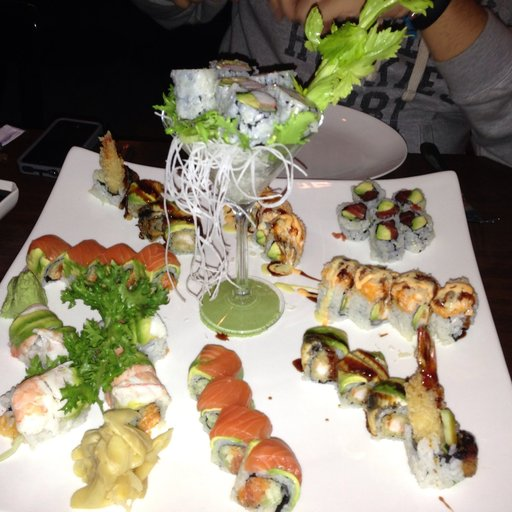

In [ ]:
import random
from PIL import  Image

# Set seed - REMOVED FOR TRUE RANDOMNESS
# random.seed(42)

# 1. get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
# print(f"image path list : {image_path_list}")

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory whre the )
image_class = random_image_path.parent.stem


# 4. open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

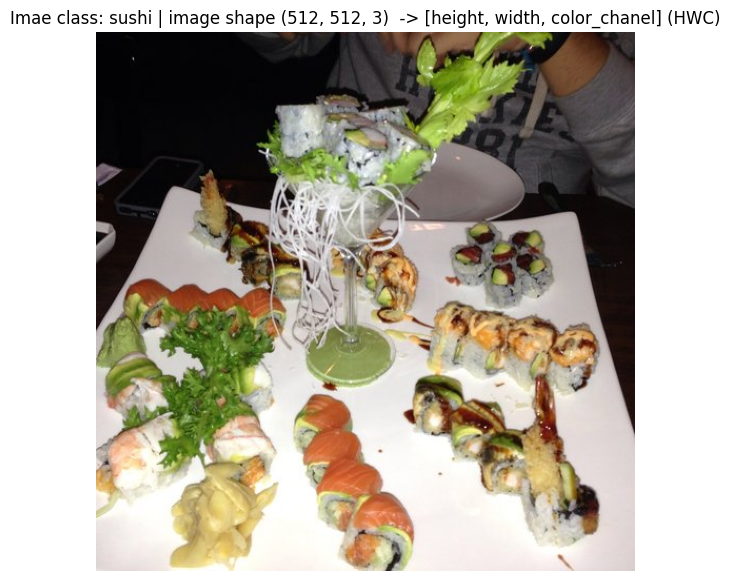

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize= (10,7))
plt.imshow(img_as_array)
plt.title(f"Imae class: {image_class} | image shape { img_as_array.shape}  -> [height, width, color_chanel] (HWC)")
plt.axis(False);

array([[[  4,   4,   6],
        [  4,   4,   6],
        [  4,   4,   6],
        ...,
        [ 56,  47,  48],
        [ 55,  49,  49],
        [ 56,  50,  50]],

       [[  4,   4,   6],
        [  4,   4,   6],
        [  4,   4,   6],
        ...,
        [ 56,  47,  48],
        [ 55,  49,  49],
        [ 55,  49,  49]],

       [[  3,   3,   5],
        [  3,   3,   5],
        [  3,   3,   5],
        ...,
        [ 55,  49,  49],
        [ 54,  48,  48],
        [ 53,  47,  47]],

       ...,

       [[224, 219, 216],
        [223, 218, 215],
        [225, 217, 215],
        ...,
        [217, 207, 206],
        [216, 206, 205],
        [216, 206, 205]],

       [[230, 225, 222],
        [229, 224, 221],
        [229, 224, 221],
        ...,
        [216, 206, 205],
        [215, 205, 204],
        [215, 205, 204]],

       [[235, 230, 227],
        [235, 230, 227],
        [234, 229, 226],
        ...,
        [215, 205, 204],
        [215, 205, 204],
        [214, 204, 203]]], dtype=uint8)
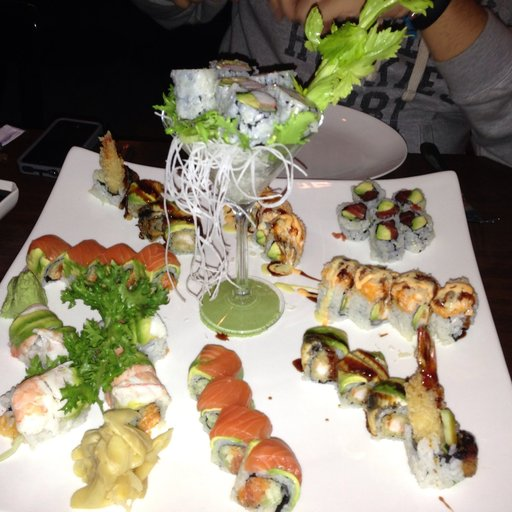

In [ ]:
img_as_array

# 3. Transforming data

Before we can use our image data with Pytorch:
1. Turn your target data into tensors (in our case, numerical representation of our images).
2. Turn it into a torch.utils.data.Dataset and sugsequently a `torch.utils.data.DataLoader`, We'll call these `dataset` and `dataloader`


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

##3.1 Transforming data with `torchvision.transforms`

Transforms help you get your images ready to be used with a model/perform data augmentation - https://pytorch.org/vision/stable/transforms.html

In [ ]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize the images to 64X64
    transforms.Resize(size=(64,64)),
    #Flip the imaages randomly on the horizintal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img)

tensor([[[0.2196, 0.2039, 0.1294,  ..., 0.0118, 0.0118, 0.0118],
         [0.2196, 0.2000, 0.1725,  ..., 0.0118, 0.0118, 0.0078],
         [0.1843, 0.1843, 0.2392,  ..., 0.0078, 0.0078, 0.0078],
         ...,
         [0.8706, 0.8784, 0.8902,  ..., 0.9373, 0.9176, 0.8941],
         [0.8627, 0.8745, 0.8824,  ..., 0.9255, 0.9098, 0.8902],
         [0.8549, 0.8667, 0.8784,  ..., 0.9098, 0.8941, 0.8824]],

        [[0.1882, 0.1765, 0.1137,  ..., 0.0118, 0.0118, 0.0118],
         [0.1961, 0.1725, 0.1294,  ..., 0.0118, 0.0118, 0.0078],
         [0.1647, 0.1490, 0.1882,  ..., 0.0078, 0.0078, 0.0078],
         ...,
         [0.8235, 0.8314, 0.8431,  ..., 0.9059, 0.8824, 0.8627],
         [0.8235, 0.8314, 0.8431,  ..., 0.8863, 0.8667, 0.8510],
         [0.8157, 0.8275, 0.8392,  ..., 0.8706, 0.8588, 0.8510]],

        [[0.1882, 0.1765, 0.1176,  ..., 0.0196, 0.0196, 0.0196],
         [0.2000, 0.1725, 0.1255,  ..., 0.0196, 0.0196, 0.0157],
         [0.1647, 0.1490, 0.1765,  ..., 0.0157, 0.0157, 0.

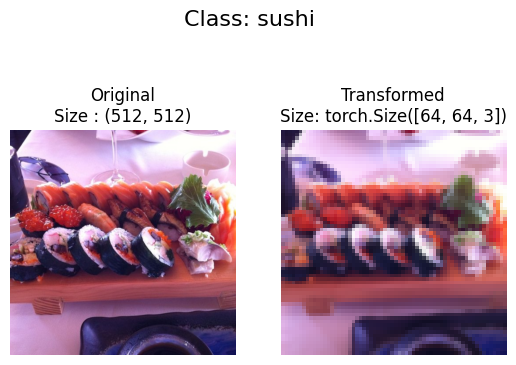

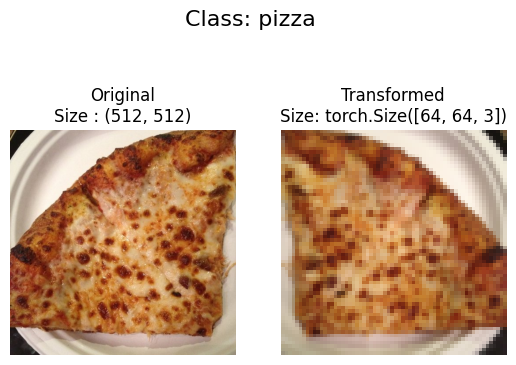

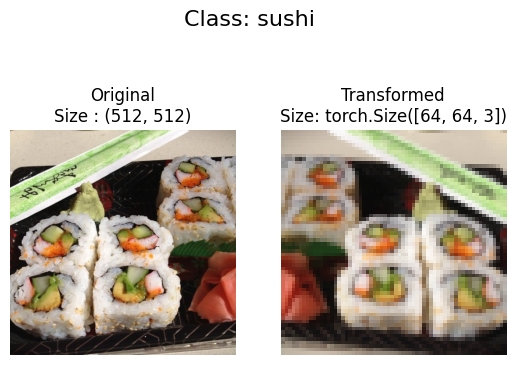

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):

    """
    Select random images from image_paths,and loads/transform them then plots the original vs the transoformed version.
    """
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize : {f.size}")
            ax[0].axis(False)

        # Transform and plot target image
        transformed_image = transform(f).permute(1,2,0) # note we will need to change shape for matplotlib (C,H,W) -> (H,W,C)
        ax[1].imshow(transformed_image)
        ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
        ax[1].axis("off")

        fig.suptitle(f"Class: {image_path.parent.stem}",
                    fontsize=16)


plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

In [ ]:
plot_transformed_images

<function __main__.plot_transformed_images(image_paths, transform, n=3, seed=42)>

## 4. option 1: Loading image data in `Imagefolder`

We can load image classification data using `torchvision.datasets.Imagefolder-`https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder

In [ ]:
from numpy.matrixlib import test
# USe Imagefolder to create datasets
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform = data_transform, # a transform for the data
                                  target_transform=None) # a transform for the label/target

test_data = datasets.ImageFolder(root=test_dir,
                                  transform = data_transform)

In [ ]:
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict


{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the length of our dataset
len(train_data), len(test_data)

(225, 75)

In [ ]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [ ]:
## index on the train_data Datasets to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"image tensor: {img}")
print(f"image shape: {img.shape}")
print(f"image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f" Label datatype: {type(label)}")

image tensor: tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Shape after permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'Image class: pizza')

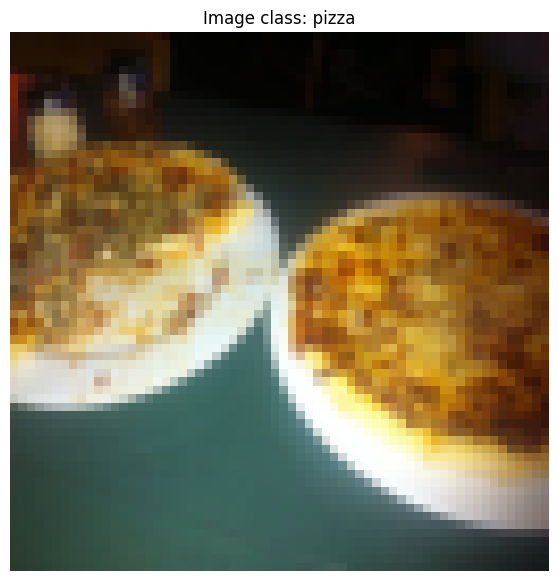

In [ ]:
# Rearrange the order dimension
img_permute = img.permute(1,2,0)

# print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Shape after permute: {img_permute.shape} -> [height, width, color_channels]")

# plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(f"Image class: {class_names[label]}")

## 4.1 Turn loaded images into `DataLoader`
A `DataLoader` is going to help our Datasets into iterables and we can customise the `batch_size` so our model can see `batch_size` images at a time

In [ ]:
import os
os.cpu_count()

2

In [ ]:
# Turn train and test dataasets into DataLoader's
from torch.utils.data import DataLoader
BATCH_SIZE =32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers = 1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              num_workers = 1,
                              shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c4776fb6fc0>,
 <torch.utils.data.dataloader.DataLoader at 0x7c4776f63ce0>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [ ]:
len(train_data) , len(test_data)

(225, 75)

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, you can change the batch size if you like
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


### 5 Option 2: Loading Image Data with a Custom Dataset

1. Want to be able to load images from file

2. Want to be able to get class names from the Dataset

3. Want to be able to get classes as dictionary from the Dataset

Pros

* Can create a Dataset out of almost anything

* Not limited to PyTorch pre-built Dataset functions

Cons:

* Even though you could create Dataset out of almost anything, it doesn't mean it will work...

* Using a custom Dataset often results in us writing more code, which could be prone to errors or performance issues

All custom datasets in Pytorch, often subclass - https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset

In [ ]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:
# instance of torchivision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

###5.1 Creating a helper function to get class names

We want a function to:

1. Get the class names using os.scandir() to traverse a target directory (ideally the directory is in standard image classification format)

2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).

3. Turn the class names into a dict and a list and return them.

In [ ]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory)) if entry.is_dir()])
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [ ]:
list(os.scandir(target_directory))


[<DirEntry 'steak'>, <DirEntry 'sushi'>, <DirEntry 'pizza'>]

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """
    Finds the class folder names in a target directory.
    """

    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}... Please check the file structure.")

    # 3. Create a dictionary of index labels (computers prefer numbers rather than strings as labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [ ]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

#### 5.2 Create a custom Dataset to replicate ImageFolder

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`

2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data.

3. Create several attributes:

* paths-paths of our images

* transform - the transform we'd like to use

classes a list of the target classes

*c lass_to_idx- a dict of the target classes mapped to integer labels

4. Create a function to `load_images()`, this function will open an image

5. Overwrite the` _ len()_` method to return the length of our dataset

6. Overwrite the`_getitem()_` method to return a given sample when passed an index

In [ ]:
# 0. write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize our custom datasets
    def __init__(self,
                 target_dir: str,
                 transform: transforms.Compose = None) -> None:

        # 3. Create class attributes
        # Get all of the image paths
        self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))
        # Setup transforms
        self.transform = transform

        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(target_dir)

    # 4. Create the fuction to load images
    def load_image(self, index: int) -> Image.Image:
        """ opens an image via path and returns it."""
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. overwrite__len__()
    def __len__(self) -> int:
        """Returns the total number of samples."""
        return len(self.paths)

    # 6. overwrite __getitem__() method to return a particular sample
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        """
        Return one sample of data. data and label(X,y).
        """
        img = self.load_image(index)
        class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img),class_idx # Return data, label(X,y)
        else:
            return img,class_idx # return untransformed image and label


In [ ]:
img, label = train_data[0]

In [ ]:
img,label

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [ ]:
# Create a transform
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [ ]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(target_dir=train_dir,
                                       transform=train_transform)

test_data_custom = ImageFolderCustom(target_dir=test_dir,
                                      transform=test_transform)


In [ ]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7c4776fedca0>,
 <__main__.ImageFolderCustom at 0x7c4777369b20>)

In [ ]:
len(train_data), len(train_data_custom)

(225, 225)

In [ ]:
len(test_data), len(test_data_custom)

(75, 75)

In [ ]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [ ]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the equality b/w original imagefolder dataset and imagefoldercustom dataset
print(train_data.classes == train_data_custom.classes)
print(test_data.classes == test_data_custom.classes)

True
True


###5.3 Create a function to display random images

1. Take in a Dataset and a number of other parameters such as class names and how many images to visualize.

2. To prevent the display getting out of hand, let's cap the number of images to see at 10.

3. Set the random seed for reproducibility

4. Get a list of random sample indexes from the target dataset.

5. Setup a matplotlib plot.

6. Loop through the random sample images and plot them with matploltib.

7. Make sure the dimensions of our images line up with matplotlib (HWC)

In [ ]:
# 1. Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str]=None,
                          n: int=10,
                          display_shape: bool = True,
                          seed: int=None
                          ):

    # 2 Adjust display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"for display, purposes, n shouldn't be larger than 10. setting to 10 and removing shape display.")

    # 3. set the seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5 Setup plot
    plt.figure(figsize=(16,8))

    # 6 Loop through random indexes and plot them with matplotlib
    for i, idx in enumerate(random_samples_idx):
        targ_image, targ_class = dataset[idx][0], dataset[idx][1]

        # 7 Adjust tensor dimension for plotting
        targ_image_adjust = targ_image.permute(1,2,0) # [C,H,W] -> [H,W,C]

        # Plot adjust samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_class]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
            plt.title(title)

In [ ]:
random.sample(range(len(train_data_custom)), k=10)

[150, 84, 157, 213, 109, 205, 108, 40, 72, 204]

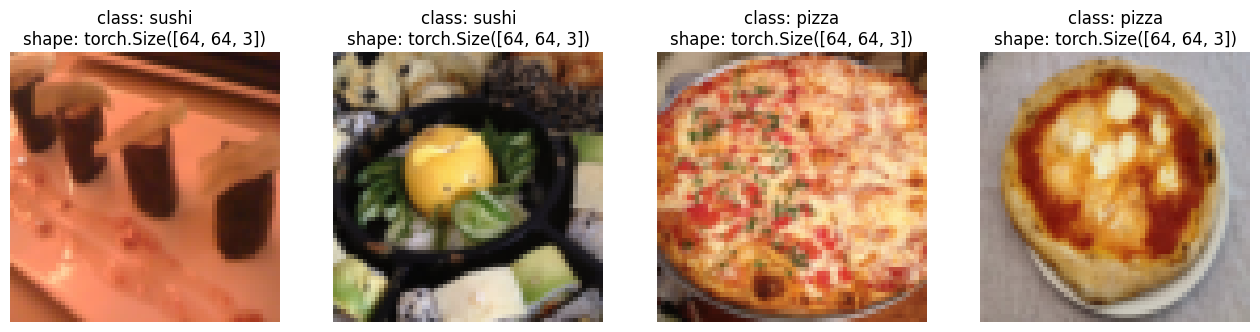

In [ ]:
# Display random images from the imagefolder created dataset
display_random_images(dataset=train_data,
                      n=4,
                      classes = class_names,
                      seed = None)

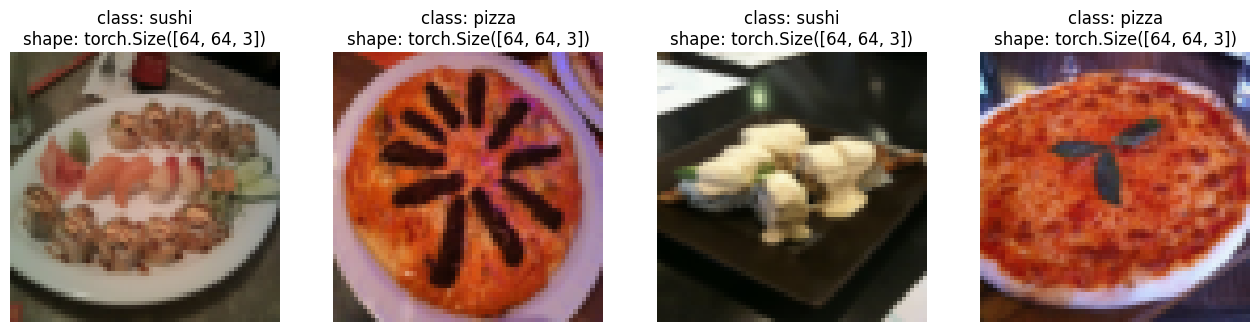

In [ ]:
# display random images from the imagefolderCustom dataset
display_random_images(dataset=train_data_custom,
                      n=4,
                      classes = class_names,
                      seed = None)

### 5.4 Turn custom loaded images into `DataLoader`'s

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                      batch_size=BATCH_SIZE,
                                      num_workers=0,
                                      shuffle=True)

test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                    batch_size =BATCH_SIZE,
                                    num_workers = 0,
                                    shuffle = False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7c4776f09040>,
 <torch.utils.data.dataloader.DataLoader at 0x7c4776e52de0>)

In [ ]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))

# print out the shapes
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

### 6. Other forms of transforms (data augmentation)

Data augmentation is the process of artificially adding diversity to your training data.

In the case of image data, this may mean applying various image transformations to the training images.

This practice hopefully results in a model that's more generalizable to unseen data.

Let's take a look at one particular type of data augmentation used to train PyTorch vision models to state of the art levels...

Blog post: https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/#break-down-of-key-accuracy:improvements

In [ ]:
# Let's look at trivailaugment https://pytorch.org/vision/stable/auto examples/plot_transforms.html#trivialaugmentwide

from torchvision import transforms

train_transform = transforms.Compose ([
    transforms.Resize(size =(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), transforms.ToTensor()

])

test_transform = transforms.Compose([
    transforms.Resize(size =(224, 224)),
    transforms. ToTensor()

])

In [ ]:
from matplotlib import image
# Get all image paths
image_path_list = list(pathlib.Path(train_dir).glob("*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/steak/1761285.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2603058.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1598345.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1647351.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1413972.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/482022.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2163079.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2881783.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1624747.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/922752.jpg')]

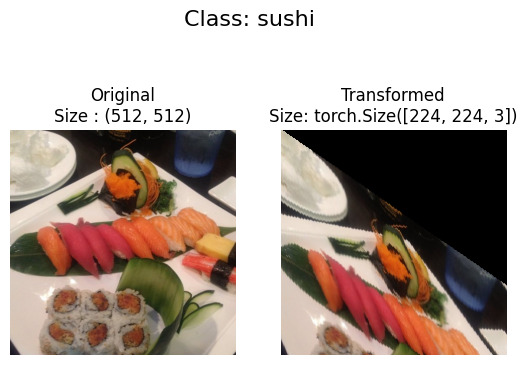

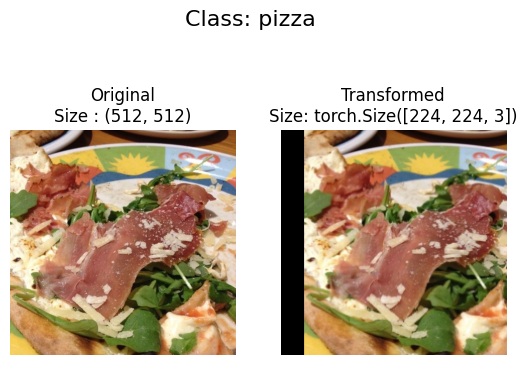

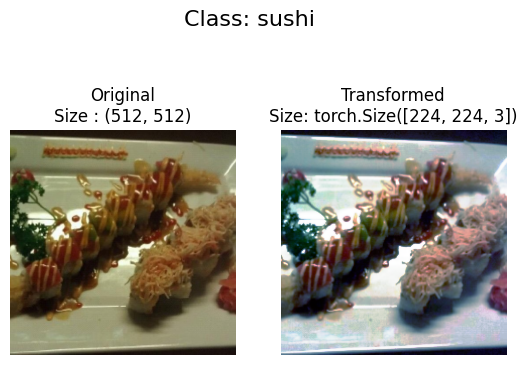

In [ ]:
# Plot random transformed images
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform,
    n=3,
    seed = None
)

## 7. Model 0: TinyVGG without data augmentation
let's replicate TinyVGG architecture from the CNN Explainer website: https://poloclub.github.io/cnn-explainer/

## 7.1 Creating transforms and loading data for Model 0


In [ ]:
# Create simple trainsform
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [ ]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform,
                                         target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                         transform=simple_transform)

# 2 Turn the datasets into Dataloader
import os
from torch.utils.data import DataLoader

# 3. Setup the batch size and number of works
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# Creating Dataloader's
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                      batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)




# 7.2 Creating TinyVGG model class


In [ ]:
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from CNN Explainer website. https://poloclub.github.io/cnn/
    """

    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)  # Default stride value is same as kernel_size
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size = 3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # Default stride value is same as kernel_size

        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            nn.Linear(in_features=hidden_units*13*13,
                      out_features=output_shape)
        )

    def forward(self,x):
        x = self.conv_block_1(x)
        print(x.shape)
        x = self.conv_block_2(x)
        print(x.shape)
        x = self.classifier(x)
        print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # benifits from operator fusion : https://horace.io/brrr_intro.html

In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_simple)).to(device)


model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=225, bias=True)
  )
)

In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_simple)).to(device)


model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=225, bias=True)
  )
)

### 7.3 Try a forward pass on a single image (to test the model)

In [ ]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape , label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
model_0(image_batch.to(device))

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 225])


tensor([[ 0.0199, -0.0145,  0.0236,  ..., -0.0403,  0.0367,  0.0013],
        [ 0.0242, -0.0176,  0.0217,  ..., -0.0407,  0.0376,  0.0006],
        [ 0.0204, -0.0145,  0.0232,  ..., -0.0366,  0.0386,  0.0055],
        ...,
        [ 0.0185, -0.0097,  0.0195,  ..., -0.0405,  0.0372,  0.0008],
        [ 0.0199, -0.0158,  0.0253,  ..., -0.0414,  0.0441, -0.0051],
        [ 0.0234, -0.0139,  0.0240,  ..., -0.0357,  0.0366,  0.0044]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

# 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [ ]:
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model=model_0,
        input_size=(1,3,64,64))

torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([1, 225])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 225]                  --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## 7.5 Create train and test loops functions

* `train_step()` - takes in a model and dataloader and trains the model on the data in the dataloader.

* `test_step()` - takes in a model and dataloader and evaluates the model on the data in the dataloader.

In [ ]:
# create train step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):

    # Put the model in train mode
    model.train()

    # setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X,y) in enumerate(dataloader):
        # send data to the target devie
        X, y = X.to(device), y.to(device)

        # 1. forward pass
        y_pred = model(X)

        # 2. calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. optimizer zero grad
        optimizer.zero_grad()

        # 4. loss backward
        loss.backward()

        # 5. optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrixs to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
# Create a test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = device):

    # put model in eval mode
    model.eval()

    # setup test loss and test accuracy values
    test_loss, test_acc = 0,0

    # turn on inference mode
    with torch.inference_mode():
        # loop through Dataloader batches
        for batch, (X,y) in enumerate(dataloader):
            # send data to the target device
            X, y = X.to(device), y.to(device)

            # 1. forward pass
            test_pred_logits = model(X)

            # 2. calculate the loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))


    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [ ]:
from tqdm.auto import tqdm
# Create a train function that takes in various model parameters + optimizer +

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn : torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model,
                                           dataloader= train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer = optimizer,
                                           device=device)

        test_loss , test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device = device)

        # 4 print out what's happinning
        print(f"Epoch: {epoch} | Train loss: {train_loss: .4f} | Train acc: {train_acc: .4f} | Test loss: {test_loss: .4f} | Test acc: {test_acc: .4f}")

        # 5 update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # 6 return the filled results at the end of the epochs
    return results

### 7.7 Train and evaluate model 0


In [ ]:
# set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

# Strart the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([1, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])
torch.Size([11, 3])
Epoch: 0 | Train loss:  1.1063 | Train acc:  0.3047 | Test loss:  1.0983 | Test acc:  0.3011
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13,

In [ ]:
print(f"Training Loss: {model_0_results['train_loss']}")
print(f"Test Loss: {model_0_results['test_loss']}")

Training Loss: [1.1063199937343597, 1.0998017340898514, 1.0868772268295288, 1.0845732241868973, 1.0661385506391525]
Test Loss: [1.0983202854792278, 1.0696791410446167, 1.080842097600301, 1.0605365832646687, 1.0655591487884521]


In [ ]:
model_0_results

{'train_loss': [1.1063199937343597,
  1.0998017340898514,
  1.0868772268295288,
  1.0845732241868973,
  1.0661385506391525],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.40234375, 0.421875],
 'test_loss': [1.0983202854792278,
  1.0696791410446167,
  1.080842097600301,
  1.0605365832646687,
  1.0655591487884521],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5729166666666666,
  0.5643939393939394]}

### 7.8 Plot the loss curves of model 0
A  **loss curve** is a way of tracking your model's progress over time.

A good guid for different loss curvesn can be found here: https://machinelearningmastery.com/loss-and-loss-functions-for

In [ ]:
# Get the model_0 result keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
def plot_loss_curves(results: dict[str , List[float]]):
    """
    Plots training curves of a results dictionary.
    """

    # Get the loss values of the results dictionary (training and testing)
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    # figure out how many epochs there were
    epoch = range(len(results["train_loss"]))

    # setup a plot
    plt.figure(figsize=(15,7))

    # plot the loss
    plt.subplot(1,2,1)
    plt.plot(epoch, loss, label="train_loss")
    plt.plot(epoch, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # plot the accuracy
    plt.subplot(1,2,2)
    plt.plot(epoch, accuracy, label="train_accuracy")
    plt.plot(epoch, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend();


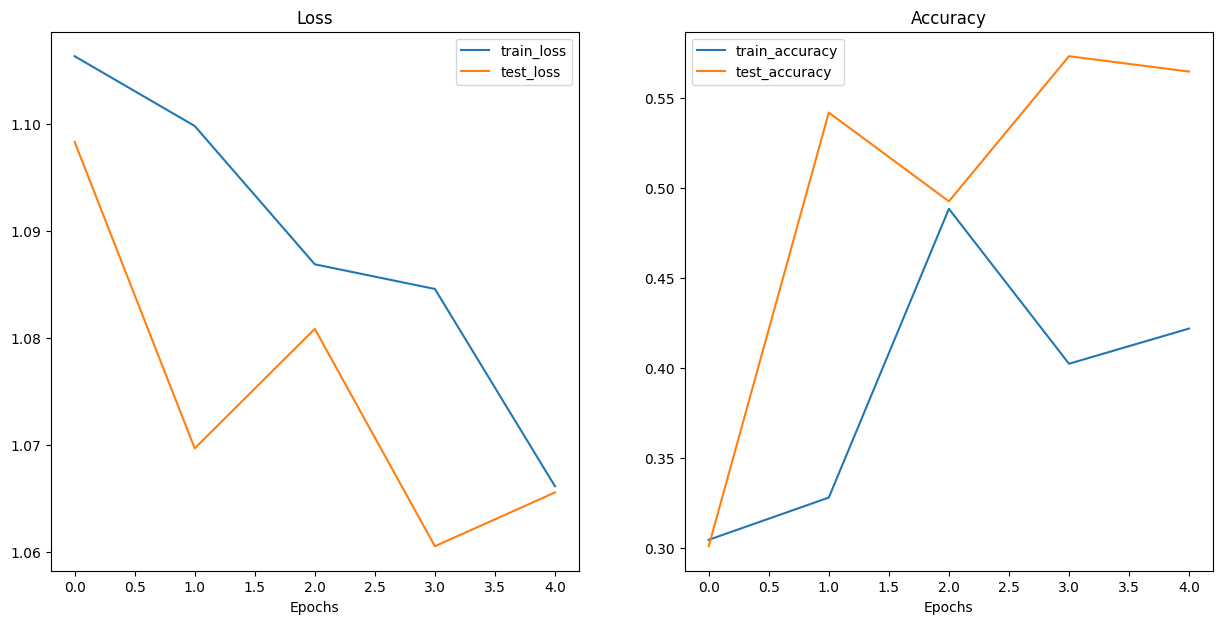

In [ ]:
plot_loss_curves(model_0_results)

## 8 What should an ideal loss curve look like ?
https://developers.google.com/machine-learning/testing-debugging/metrix/interpretic

A loss curve is one of the most helpful ways to troubleshoot a model

### 9. Model 1: TinyVGG with Data Augmentation

now let's try another modelling experiment this time using the same model as before with some data augmentation.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 9.1 Create transform with data augmentation


In [ ]:
# Create training transform with TrivialAugment

from torchvision import transforms

train_transform_trivial = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])


###9.2 Create train and test `Dataset`'s `DataLoader`'s with data augmentation

In [ ]:
# Turn image folders into Datasets
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                  transform=train_transform_trivial,
                                #   target_transform=None
                                         )
test_data_augmented = datasets.ImageFolder(root=test_dir,
                                  transform=test_transform_simple)


In [ ]:
# Turn our Datasets into DataLoaders
import os
from torch.utils.data import DataLoader

# 3. Setup the batch size and number of works
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented =DataLoader(dataset=train_data_augmented,
                                       batch_size=BATCH_SIZE,
 shuffle=True,
num_workers=NUM_WORKERS)

test_dataloader_augmented =DataLoader(dataset=test_data_augmented,
                                      batch_size=BATCH_SIZE,
 shuffle=False,
num_workers=NUM_WORKERS)

### 9.3 Construct and train model 1

This time we'll be using the same model architecture except this we've augmented the training data.


In [ ]:
# Create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_simple.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

Wonderful! Now we've a model and dataloaders, let's create a loss function and an optimizer and call upon our train function.
and evaluate our model

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
NUM_EPOCHS = 15

# Setup loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model 1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_augmented,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print out how long it took
end_time = timer()

print(f"Total training time for model: {end_time-start_time:.3f} seconds")

  0%|          | 0/15 [00:00<?, ?it/s]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([1, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])
torch.Size([11, 3])
Epoch: 0 | Train loss:  1.1049 | Train acc:  0.2500 | Test loss:  1.1019 | Test acc:  0.2604
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13,

In [ ]:
model_1_results

{'train_loss': [1.104913741350174,
  1.0806787312030792,
  1.0712232291698456,
  1.1253773868083954,
  1.0858341455459595,
  1.0861556828022003,
  1.07279834151268,
  1.081614837050438,
  1.0817397385835648,
  1.0048195645213127,
  0.9750484302639961,
  0.9547349289059639,
  0.960972011089325,
  1.003804698586464,
  0.9460553377866745],
 'train_acc': [0.25,
  0.42578125,
  0.42578125,
  0.3046875,
  0.42578125,
  0.37890625,
  0.49609375,
  0.36328125,
  0.42578125,
  0.43359375,
  0.55859375,
  0.45703125,
  0.55078125,
  0.53515625,
  0.5859375],
 'test_loss': [1.1019272804260254,
  1.12608802318573,
  1.1592472990353901,
  1.158070166905721,
  1.1551163991292317,
  1.143226186434428,
  1.1343460877736409,
  1.1251472632090251,
  1.0858290990193684,
  0.9604202508926392,
  0.9940198063850403,
  1.0262444416681926,
  1.0129478772481282,
  1.057130257288615,
  1.0750266710917156],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.33

### 9.4 plot the loss curves of model 1
A loss curve helps you evaluate your models performance overtime.


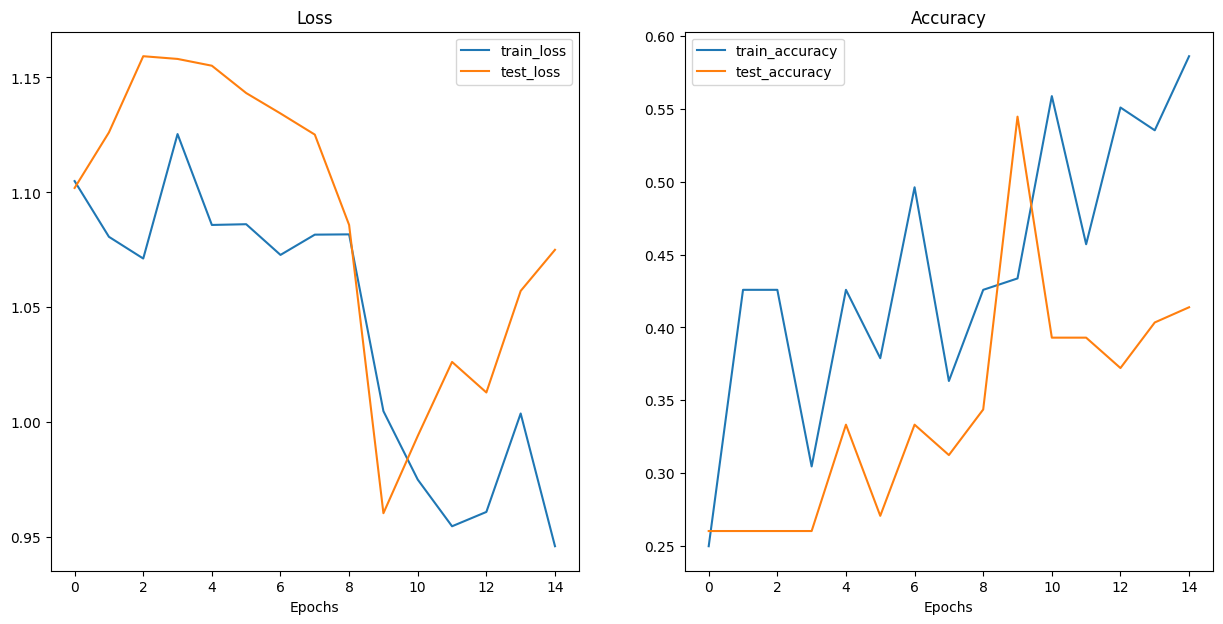

In [ ]:
plot_loss_curves(model_1_results)

## 10. Compare model results

After evaluating our modelling experiments on their own, it's important to compare them to each other.

There's a few different ways to do this:

1. Hard coding (what we're doing)

2. PyTorch + Tensorboard - https://pytorch.org/docs/stable/tensorboard.html

3. Weights & Biases - https://wandb.ai/site/experiment-tracking

4. MLFlow - https://mlflow.org/

In [ ]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106320,0.304688,1.098320,0.301136
1,1.099802,0.328125,1.069679,0.541667
2,1.086877,0.488281,1.080842,0.492424
3,1.084573,0.402344,1.060537,0.572917
4,1.066139,0.421875,1.065559,0.564394


In [ ]:
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.104914,0.250000,1.101927,0.260417
1,1.080679,0.425781,1.126088,0.260417
2,1.071223,0.425781,1.159247,0.260417
3,1.125377,0.304688,1.158070,0.260417
4,1.085834,0.425781,1.155116,0.333333
5,1.086156,0.378906,1.143226,0.270833
6,1.072798,0.496094,1.134346,0.333333
7,1.081615,0.363281,1.125147,0.312500
8,1.081740,0.425781,1.085829,0.343750
9,1.004820,0.433594,0.960420,0.544508


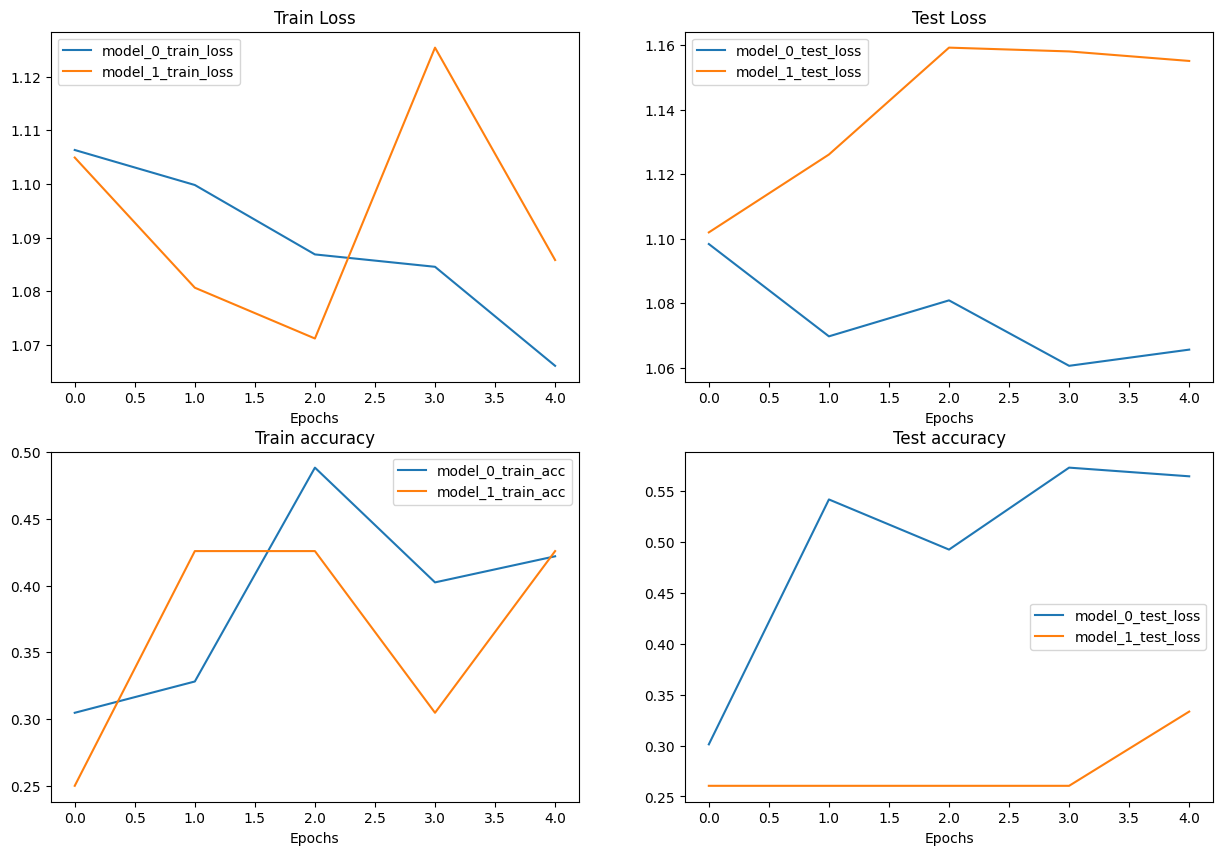

In [ ]:
import matplotlib.pyplot as plt

# Setup a plot
plt.figure(figsize=(15,10))

# Get number of epochs from model_0_df
epochs = range(len(model_0_df))

# Truncate model_1_df to match the length of model_0_df
model_1_df_truncated = model_1_df.head(len(model_0_df))

# plot train loss
plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"], label="model_0_train_loss")
plt.plot(epochs, model_1_df_truncated["train_loss"], label="model_1_train_loss")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# plot test loss
plt.subplot(2,2,2)
plt.plot(epochs, model_0_df["test_loss"], label="model_0_test_loss")
plt.plot(epochs, model_1_df_truncated["test_loss"], label="model_1_test_loss")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# plot train_acc
plt.subplot(2,2,3)
plt.plot(epochs, model_0_df["train_acc"], label="model_0_train_acc")
plt.plot(epochs, model_1_df_truncated["train_acc"], label="model_1_train_acc")
plt.title("Train accuracy")
plt.xlabel("Epochs")
plt.legend()

# plot test_accuracy
plt.subplot(2,2,4)
plt.plot(epochs, model_0_df["test_acc"], label="model_0_test_loss")
plt.plot(epochs, model_1_df_truncated["test_acc"], label="model_1_test_loss")
plt.title("Test accuracy")
plt.xlabel("Epochs")
plt.legend();

### 11. Making a prediction on a custom image
Although we've trained a model on custom data... how do you make a prediction on a sample/image that's not in either training or testing datasets

In [ ]:
# Download custom image
import requests


# setup custom image path
custom_image_path = Path("data/") / "custom_image.jpeg"

# Downloading the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # downloading any requested website or github raw link use
        request = requests.get("https://scontent.fidr4-1.fna.fbcdn.net/v/t39.30808-6/515110371_1200836745175793_9015386436680080976_n.jpg?stp=cp6_dst-jpg_tt6&_nc_cat=106&ccb=1-7&_nc_sid=13d280&_nc_ohc=T8JN5IXmhT4Q7kNvwFckW4Z&_nc_oc=AdoItAIYMVHkFzzlMiG3DpkVIvkPHP5xoP1xPrijt6yeyLjH4ArnfPqx5e3M34H3IWMw8NS11M58-S2_sSe-pn1c&_nc_zt=23&_nc_ht=scontent.fidr4-1.fna&_nc_gid=uLsgETzPlCkp6WdWL2sxCQ&_nc_ss=7a32e&oh=00_AfzNJ6wT1necYJgMSnhqOp163bDZTvTUTJPx_nDjGKRYEw&oe=69CA18B5")
        print("Downloading custom image...")
        f.write(request.content)
else:
    print("Custom image already exists , skipping download...")

### 11.1 Loading in a custom image with PyTorch

we have to make sure our custom image is in the same format as the data our model was trained datatype(torch.float32)

* In tensor form with datatype (torch.float32)
* Of shape 64X64X3
* On the right device

We can read an image into PyTorch using - https://docs.pytorch.org/vision/0.19/generated/torchvision.io.read_image.html


In [ ]:
custom_image_path

PosixPath('data/custom_image.jpeg')

In [ ]:
import torchvision

# Read in custom image
custom_image_unit8  = torchvision.io.read_image(str(custom_image_path))
print(f"custom image tensor: \n {custom_image_unit8}")
print(f"custom image shape: \n {custom_image_unit8.shape}")
print(f"custom image datatype: \n {custom_image_unit8.dtype}")

RuntimeError: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.

In [ ]:
plt.imshow(custom_image_unit8.permute(1,2,0))

NameError: name 'custom_image_unit8' is not defined

### 11.2 Making a prediction on a custom image with a trained PyTorch model


In [ ]:
# Load in the custom image and convert to torch.float32
custom_image_unit8 = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)/255
custom_image_unit8.shape

RuntimeError: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.

In [ ]:
plt.imshow(custom_image_unit8.permute(1,2,0))


NameError: name 'custom_image_unit8' is not defined

In [ ]:
# Create transform pipeline to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64,64))
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image_unit8)

print(f"Original shape : {custom_image_unit8.shape}")
print(f"Transformed shape : {custom_image_transformed.shape}")

NameError: name 'custom_image_unit8' is not defined

In [ ]:
plt.imshow(custom_image_transformed.permute(1,2,0))

NameError: name 'custom_image_transformed' is not defined

In [ ]:
custom_image_transformed.shape, custom_image_transformed.unsqueeze(0).shape


NameError: name 'custom_image_transformed' is not defined

In [ ]:
# Try to make a prediction on an image in uint8 format
model_1.eval()
with torch.inference_mode():
    custome_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))

custome_image_pred

NameError: name 'custom_image_transformed' is not defined

Note, to make a prediction on a custom image we had to:

* Load the image and turn it into a tensor

* Make sure the image was the same datatype as the model (torch.float32)

* Make sure the image was the same shape as the data the model was trained on (3, 64, 64) with a batch size... (1, 3, 64, 64)

* Make sure the image was on the same device as our model

1

In [ ]:
# convert logits -> prediction probabilities
custome_image_pred_probs = torch.softmax(custome_image_pred, dim=1)
custome_image_pred

NameError: name 'custome_image_pred' is not defined

In [ ]:
# Convert prediction probabilities -> prediction labels
custome_image_pred_label = torch.argmax(custome_image_pred_probs, dim=1)
custome_image_pred_label

NameError: name 'custome_image_pred_probs' is not defined

### 12. Model 2: TinyVGG with Transfer Learning (ResNet18)

#### 12.1 Create Transforms and DataLoaders for Transfer Learning

In [ ]:
import torchvision
from torchvision import transforms

# Create a transform for the data (all images will be resized to 224x224)
# Normalization parameters are standard for pre-trained ImageNet models
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # VGG models generally use 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3-channel (RGB) mean for ImageNet
                         std=[0.229, 0.224, 0.225])  # 3-channel (RGB) std for ImageNet
])

# Create training and testing datasets
train_data_transfer = torchvision.datasets.ImageFolder(root=train_dir,
                                                      transform=manual_transforms)
test_data_transfer = torchvision.datasets.ImageFolder(root=test_dir,
                                                     transform=manual_transforms)

# Create DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_transfer = DataLoader(dataset=train_data_transfer,
                                        batch_size=BATCH_SIZE,
                                        num_workers=NUM_WORKERS,
                                        shuffle=True)
test_dataloader_transfer = DataLoader(dataset=test_data_transfer,
                                       batch_size=BATCH_SIZE,
                                       num_workers=NUM_WORKERS,
                                       shuffle=False)

print(f"Number of training batches: {len(train_dataloader_transfer)}")
print(f"Number of testing batches: {len(test_dataloader_transfer)}")

Number of training batches: 8
Number of testing batches: 3


#### 12.2 Load Pre-trained ResNet18 and Modify Classifier

In [ ]:
from torchvision import models

# Load a pre-trained ResNet18 model
model_2 = models.resnet18(pretrained=True)

# Freeze all base parameters (feature extraction layers)
for param in model_2.parameters():
    param.requires_grad = False

# Get the number of input features for the classifier layer
num_ftrs = model_2.fc.in_features

# Replace the classifier head with a new one for our number of classes
# Our dataset has 3 classes: pizza, steak, sushi
model_2.fc = nn.Linear(num_ftrs, len(train_data_transfer.classes))

# Move model to device
model_2 = model_2.to(device)

# Print the model to see the changes
print(model_2)

# Summary of the model
summary(model=model_2,
        input_size=(1, 3, 224, 224), # ResNet18 expects 224x224 input
        col_names=["input_size", "output_size", "num_params"],
        col_width=20,
        row_settings=["var_names"])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Layer (type (var_name))                  Input Shape          Output Shape         Param #
ResNet (ResNet)                          [1, 3, 224, 224]     [1, 3]               --
├─Conv2d (conv1)                         [1, 3, 224, 224]     [1, 64, 112, 112]    (9,408)
├─BatchNorm2d (bn1)                      [1, 64, 112, 112]    [1, 64, 112, 112]    (128)
├─ReLU (relu)                            [1, 64, 112, 112]    [1, 64, 112, 112]    --
├─MaxPool2d (maxpool)                    [1, 64, 112, 112]    [1, 64, 56, 56]      --
├─Sequential (layer1)                    [1, 64, 56, 56]      [1, 64, 56, 56]      --
│    └─BasicBlock (0)                    [1, 64, 56, 56]      [1, 64, 56, 56]      --
│    │    └─Conv2d (conv1)               [1, 64, 56, 56]      [1, 64, 56, 56]      (36,864)
│    │    └─BatchNorm2d (bn1)            [1, 64, 56, 56]      [1, 64, 56, 56]      (128)
│    │    └─ReLU (relu)                  [1, 64, 56, 56]      [1, 64, 56, 56]      --
│    │    └─Conv2d (conv2)      

#### 12.3 Train Model 2 with Transfer Learning

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
NUM_EPOCHS = 10 # Start with a reasonable number of epochs for fine-tuning

# Setup loss function and optimizer (only optimize the new classifier layer)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.fc.parameters(), # Only optimize parameters of the new classifier layer
                             lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_2
model_2_results = train(model=model_2,
                        train_dataloader=train_dataloader_transfer,
                        test_dataloader=test_dataloader_transfer,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time for model 2: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | Train loss:  1.1350 | Train acc:  0.4453 | Test loss:  1.2784 | Test acc:  0.3021
Epoch: 1 | Train loss:  1.0595 | Train acc:  0.4805 | Test loss:  0.9305 | Test acc:  0.5862
Epoch: 2 | Train loss:  0.8915 | Train acc:  0.5312 | Test loss:  0.9468 | Test acc:  0.6392
Epoch: 3 | Train loss:  0.8342 | Train acc:  0.6406 | Test loss:  0.7936 | Test acc:  0.7424
Epoch: 4 | Train loss:  0.7896 | Train acc:  0.6523 | Test loss:  0.8204 | Test acc:  0.6809
Epoch: 5 | Train loss:  0.7495 | Train acc:  0.6953 | Test loss:  0.7000 | Test acc:  0.7008
Epoch: 6 | Train loss:  0.6136 | Train acc:  0.8516 | Test loss:  0.7485 | Test acc:  0.6913
Epoch: 7 | Train loss:  0.7281 | Train acc:  0.6445 | Test loss:  0.6877 | Test acc:  0.7538
Epoch: 8 | Train loss:  0.6703 | Train acc:  0.7109 | Test loss:  0.6089 | Test acc:  0.7519
Epoch: 9 | Train loss:  0.6911 | Train acc:  0.6875 | Test loss:  0.4900 | Test acc:  0.8438
Total training time for model 2: 16.194 seconds


#### 12.4 Plot the Loss Curves of Model 2

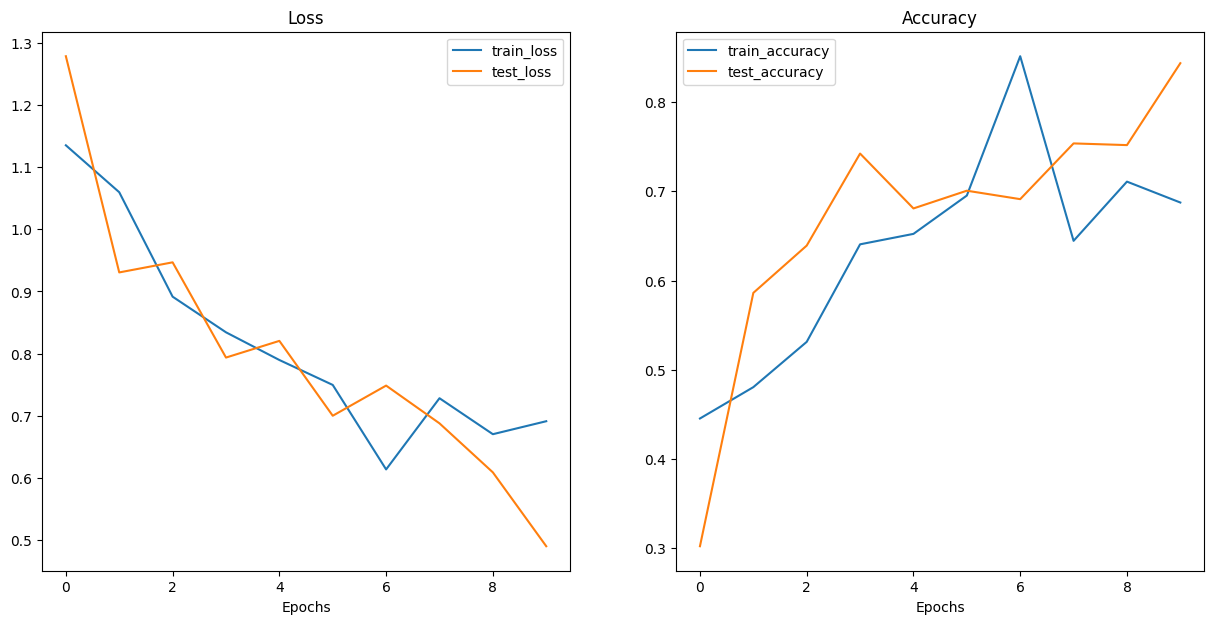

In [ ]:
plot_loss_curves(model_2_results)

#### 12.5 Re-evaluate custom image prediction with Model 2

In [ ]:
# Load in the custom image as PIL Image
from PIL import Image
custom_image_pil = Image.open(custom_image_path)

# Apply the same transform as used for Model 2 training
custom_image_transformed_model2 = manual_transforms(custom_image_pil)

# Make a prediction with Model 2
model_2.eval()
with torch.inference_mode():
    custom_image_pred_model2_logits = model_2(custom_image_transformed_model2.unsqueeze(0).to(device))

# Convert logits to prediction probabilities
custom_image_pred_model2_probs = torch.softmax(custom_image_pred_model2_logits, dim=1)

# Convert prediction probabilities to prediction labels
custom_image_pred_model2_label = torch.argmax(custom_image_pred_model2_probs, dim=1)

# Get the predicted class name
predicted_class_name_model2 = class_names[custom_image_pred_model2_label]

print(f"Predicted class name for custom image (Model 2): {predicted_class_name_model2}")
print(f"Prediction probabilities (Model 2): {custom_image_pred_model2_probs}")

UnidentifiedImageError: cannot identify image file 'data/custom_image.jpeg'

In [ ]:
# Try to make a prediction on an image in uint8 format
model_1.eval()
with torch.inference_mode():
    custome_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))

custome_image_pred

In [ ]:
# convert logits -> prediction probabilities
custome_image_pred_probs = torch.softmax(custome_image_pred, dim=1)
custome_image_pred_probs

In [ ]:
# Convert prediction probabilities -> prediction labels
custome_image_pred_label = torch.argmax(custome_image_pred_probs, dim=1)
custome_image_pred_label

In [ ]:
class_names[custome_image_pred_label]

In [ ]:
class_names[custome_image_pred_label]

## 11.3 Putting custom image prediction together : building a function

ideal custom:
A function where we pass an image path to and have our model predict on that image and plot the image + prediction.

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                       image_path: str,
                        class_names: List[str]=None,
                        transforms=None,
                        device: torch.device=device):
    """Make a prediction on a target image with a trained model and plots the image and prediction. """

    # Load the image
    target_image = torchvision.io.read_image(str(image_path))

    # Divide the image pixel values by 255 to get them between [0,1]
    target_image = target_image / 255.


    # Transform if neccessary
    if transforms:
        target_image = transforms(target_image)

    # Make sure the model is on the target device
    model.eval() # Corrected line: removed (device)

    # Turn on eval/inference mode and make a prediction
    with torch.inference_mode():
        # Add an extra dimension to the image (this is the batch dimension, e.g our model will predict on batches of 1x.image)
        target_image = target_image.unsqueeze(dim=0)

        # make a prediction on the image awith an extra dimension
        target_image_pred = model(target_image.to(device))

    # Convert logits -> prediction probabilities
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # convert predition probabilities -> prediction label
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Plot the image alonside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1,2,0)) # remove batch dimension and rearrange shape to be HWC

    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"

    plt.title(title)
    plt.axis(False)

In [ ]:
# pred on our custom image
pred_and_plot_image(model = model_1,
                    image_path = custom_image_path,
                    class_names= class_names,
                    transforms = custom_image_transform,
                    device = device)